# How does Gender Diversity in Investment Teams affect their Portfolio Performance?

Name: Sara Romero Banfalvi

Student ID: 1517710

---

# Abstract


We build a discrete-time, stochastic behavioural-finance model to answer the question of: How does team gender diversity $D$ affect how cognitive biases $B$ impact misvaluation $M$, and how might it act as a hedge against market shocks $S$ and volatility $V$ conditions, ultimately affecting the investment team portfolio performance 
$P$? Four biases, overconfidence $O$, loss aversion $L$, heuristics $H$, and herding $R$, aggregate into a Bias Index $B$, with diversity acting as a non-linear dampener $D^{γ}$. Across different parameters, D shows lower $B$ and raises mean $P$, with the largest gains arising as diversity moves away from homogeneity. Under stress (negative $S$, high $V$), diversity functions as a partial hedge. Benefits often taper at moderate $D$ when $γ<1$. Dispersion in outcomes is driven primarily by $S$ and $V$, and not by $D$.

# Introduction

Studies on behavioural finance and behavioural economics have identified cognitive biases that lead to investor sentiment, defined as the irrational components of investor's behavioural biases which lead to stock market misvaluation. Research into behavioural finance through a gender lens approach suggests that an increase in gender diversity in teams of investment decision-makers has the potential to decrease these biases, leading to more rational investment decisions.

This project formalises a behavioural-finance system, linking a team's gender diversity to portfolio outcomes through its impact on investor biases, which in turn affect misvaluation and portfolio performance. We ask the question of _How does team gender diversity modify the effect of biases (Overconfidence, Loss Aversion, Heuristics, and Herding) in Misvaluation and Portfolio Performance, and might hedge against market Shocks and Volatility?_

To answer this, we build a discrete-time, stochastic model, aggregating the four biases into a Bias Index, with diversity acting as a non-linear dampener, and Stocks and Volatility introducing real-world noise.

# Background

This study models how cognitive factors and team composition shape market outcomes under real-world uncertainty.
The system centres on four cognitive biases; overconfidence, loss aversion, heuristics, and herding, which aggregate into a Bias Index $B∈[0,1]$. The Bias Index and market shocks $S∈[−1,1]$ raise misvaluation $M$, which in turn lowers portfolio performance $P$. Gender diversity $D∈[0,1]$ is modelled as a structural dampener of biases and, through that channel, as a positive driver of performance. Volatility $V$ captures the noisiness of signals that feed heuristics and herding, and links shocks to predictability.

**Cognitive Biases and the Bias Index:**

Following Tversky & Kahneman (1974), investors rely on systematic shortcuts that distort belief formation and updating.
We model overconfidence $O$ as the tendency to overweight private signals and under-react to disconfirming evidence; loss aversion $L$ as asymmetric sensitivity to losses that can induce risk-seeking in the loss domain; heuristics $H$ as rule-of-thumb reliance that rises when signals are noisy and attention is scarce; and herding $R$ as flow toward consensus positions under salient market moves. These components combine as $B=0.3O+0.25L+0.25H+0.2R$, giving overconfidence the largest weight due to its strong link to excess trading and misvaluation (Barber & Odean, 2001). Higher $B$ increases misvaluation $M$, which depresses performance $P$.

**Gender Diversity as Structural Dampening:**

Gender diversity reduces the expression of biases through improved due diligence, challenging norms, and more disciplined risk management. This is supported empirically, with research showing that men trade more and earn lower net returns due to overconfidence (Barber & Odean, 2001).
We encode diversity as a non-linear effective input $D^{γ}$ to allow diminishing returns or threshold effects; by default we set $γ=0.5$ (early gains from moving away from homogeneity), with robustness considered against $γ=1$ (linear) and $γ>1$ (critical mass, where low diversity has little effect on teams decisions until it crosses a threshold). In the equations, higher D lowers $O,L,H$, and $R$, thereby reducing $B$ and improving $P$.

**Shocks, Volatility, and Predictability:**

Exogenous market shocks $S$ model policy changes, geopolitical events, and disasters that raise uncertainty and volatility $V$, reducing the predictability of returns (Bloom, 2009). In the model, $S$ directly shifts $O$ and $L$ (with asymmetric effects for negative vs positive shocks), amplifies $R$ via large-move salience, and, through V, elevates $H$. This captures the mechanism through which shocks increase signal noise, decrease signal quality, increase attention-driven reactions, and tilt sentiment toward irrationality. We explicitly test whether higher $D$ hedges performance in high-volatility/shock states or remain neutral.

# Methods

## Relationship Between Variables

This is a discrete-time, stochastic model evaluated period-by-period (e.g., a quarter). While the variables $O,L,H,R,B,M,P$ are deterministic and conditional on inputs, exogenous market shocks $S$ and volatility $V$ are stochastically generated (with both fixed distributions and random seed for reproducibility).
Four cognitive biases (Overconfidence $O$, Loss Aversion $L$, Heuristics $H$, and Herding $R$) aggregate into a Bias Index $B∈[0,1]$. Gender diversity $D∈[0,1]$ dampens each bias component (thus lowering $B$) and improves performance $P$. Exogenous market shocks $S∈[−1,1]$ and volatility $V∈[0,1]$ elevate $H$ (through noisy signals), $R$ (through salient moves), shift $O$ and $L$ in opposite directions, and reduce fundamentals-based predictability. As $B$ rises, misvaluation $M$ increases and performance falls. This design maps directly to the relationships studied in literature (Tversky & Kahneman, 1974; Barber & Odean, 2001; Bloom, 2009; Ahmad & Ali, 2022).

![Diagram](Methods_Diagram.jpg)

## Defining Variables

**Independent Variables**

1. Diversity $D∈[0,1]$: $0 =$ all-male; $1 = 50/50$ split. For $0≤D≤0.5$ male-dominant; for $0.5<D≤1$ female-dominant.

2. Market Shocks $S∈[−1,1]$: −1 = large negative shock, which decreases performance by more than 50%, 0 = no shocks (and hence no effect on performance), 1 = positive shock, which improved performance by more than 50% (unitless).
   
3. Volatility $V∈[0,1]$: exogenous noise level, 0 = no noise, 1 = random performance.

**Dependent Variables**

4. Bias Index $B∈[0,1]$: aggregate of $O,L,H,R$.

5. Misvaluation $M∈[0,1]$: Percentage difference between actual and predicted stock performance, driven by $B$ and $S$
   
6. Performance $P∈[−20,20]$ (percent): Reasonable range for quarterly/yearly portfolio returns.


## Equations

**Diversity**
$$ D_e=D^{γ} $$

- $γ=1$: linear dampening;
- $0<γ<1$: diminishing returns (default $γ=0.5$);
- $γ>1$: critical-mass effect
  

**Overconfidence**
$$ O= 0.5+0.4S+0.2S^{2}-0.3D_e-0.1D_e^{2} $$

The $0.5$ value acts as a baseline level, to account for the assumption that most individuals will not be bias-free. Given O ranges between $[0,1]$, 0.5 is a safe middle level that allows other factors, such as Shocks and Diversity, to have a dominant effect.

$+0.40S$: Overconfidence is proportional to positive shocks.

$+0.20S^{2}$: Very good periods boost confidence more than proportionally.

$−0.30D_e−0.10D_e^{2}$: Diversity dampens bias with diminishing returns as teams approach balance.


**Loss Aversion**

$$ L= 0.5-0.6S+0.2S^{2}-0.3D_e-0.1D_e^{2} $$

$-0.6S$: Loss aversion is indirectly proportional to shocks (i.e. bad news), hence the negative sign. When negative shocks occur, investors enter the realm of losses, increasing their loss aversion and hence becoming risk-seeking. The magnitude at which Shocks affect Loss Aversion is higher than with overconfidence, as per loss aversion's definition that losses have a higher impact on utility than gains of the same amount.

$+0.2S^{2}$: Very large moves (even positive) can still elevate fear and caution that the upwards trend will eventually end, as individuals decide it is time to sell, rather than buy.

$−0.30D_e−0.10D_e^{2}$: As with overconfidence, gender diversity acts as a structural dampener that moves away from short-term trends and pushes for more due diligence, with diminishing marginal utilities as D tends to 1.


**Heuristics**
$$ H= 0.5+0.5V+0.2V^{2}-0.3D_e-0.1D_e^{2} $$

$+0.5V$: Heuristics increase with volatility, when attention is scarce and signals are noisy. Noisy signals reduce investors' ability to trust historical data or financial models to predict the performance of stocks, which causes them to lean towards trusting rules-of-thumb (Bloom, 2009).

$+0.2V^{2}$: Very high volatility produces disproportionate reliance on heuristics.

$-0.3D_e-0.1D_e^{2}$: Diversity dampens shortcuts used to predict performance by increasing due diligence and patience to wait for volatility to decrease.


**Herding Behaviour**

$$R = 0.3+0.3S^{2}+0.2V-0.3D_e-0.1D_e^{2} $$

$0.3$ Baseline Level: Herding Behaviour is more common in inexperienced or amateur investors, hence there will be a lower baseline level.

$+0.3S^{2}$: Herding Behaviour increases with the **magnitude** of the market moves.

$+0.1V$: Noisy markets further channel flows into the general movement of the market.

$-0.3D_e-0.1D_e^{2}$: Diversity dampens crowd-following via more internal challenge and less attention-driven decision-making.


**Bias Index**

$$ B= 0.3O+0.25L+0.25H+0.2R $$

Weights reflect documented links to excess trading/misvaluation.


**Misvaluation**

$$M=B-0.5S$$

Biases raise $M$; negative shocks increase $M$ and subsequent $P$ more than positive shocks reduce it.


**Performance**

$$ P=(0.1-0.2M) \cdot 100 $$

A higher $M$ lowers $P$; $0.1$ encodes a $10$% average return benchmark.

## Code

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Allows to change variables later on
def model(
    S_fixed=None, 
    V_fixed=None, 
    n_draws=300, # simulating 300 random worlds
    seed=42, 
    gamma=0.5):
# Running random worlds (Monte Carlo) for each D value
    rng = np.random.default_rng(seed)
    diversity = np.linspace(0, 1, 51)
#stores performance & bias stats
    perf_mean, perf_p10, perf_p90 = [], [], []
    bias_mean, bias_p10, bias_p90 = [], [], []

    for D in diversity:
        # draws random values, or allows to change variables
        S = np.full(n_draws, S_fixed) if S_fixed is not None else np.clip(rng.normal(0, 0.35, n_draws), -1, 1)
        V = np.full(n_draws, V_fixed) if V_fixed is not None else np.clip(rng.normal(0, 0.35, n_draws), -1, 1)

        # non-linear diversity
        D_eff = D**gamma

        # Core Model Equations
        O = 0.5+0.4*S+0.2*S**2-0.3*D_eff-0.1*D_eff**2
        L = 0.5-0.6*S+0.2*S**2-0.3*D_eff-0.1*D_eff**2
        H = 0.5+0.5*V+0.2*V**2-0.3*D_eff-0.1*D_eff**2
        R = 0.3+0.3*S**2+0.2*V-0.3*D_eff-0.1*D_eff**2

        B = 0.3*O+0.25*L+0.25*H+0.2*R
        B = np.clip(B, 0, 1)
        M = np.clip(B-0.5*S, 0, 1)
        P = (0.1-0.2*M)*100

        # stats
        perf_mean.append(P.mean());  
        perf_p10.append(np.percentile(P, 10));  
        perf_p90.append(np.percentile(P, 90))
        bias_mean.append(B.mean());  
        bias_p10.append(np.percentile(B, 10));  
        bias_p90.append(np.percentile(B, 90))

# plot
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(diversity, perf_mean, label="Performance mean (%)")
    ax1.fill_between(diversity, perf_p10, perf_p90, alpha=0.2)
    ax1.set_xlabel("Gender Diversity (0 = none, 1 = balanced)")
    ax1.set_ylabel("Performance (%)")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(diversity, bias_mean, linestyle="--", label="Bias mean (0–1)")
    ax2.fill_between(diversity, bias_p10, bias_p90, alpha=0.15)
    ax2.set_ylabel("Bias Index (0–1)")

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")

    tS = "random" if S_fixed is None else f"{S_fixed}"
    tV = "random" if V_fixed is None else f"{V_fixed}"
    plt.title(f"Diversity vs Performance & Bias (S={tS}, V={tV})")
    plt.show()

    return {
        "D": diversity,
        "perf_mean": np.array(perf_mean), 
        "perf_p10": np.array(perf_p10), 
        "perf_p90": np.array(perf_p90),
        "bias_mean": np.array(bias_mean), 
        "bias_p10": np.array(bias_p10), 
        "bias_p90": np.array(bias_p90),
    }

# Results

### Random, Diminishing Diversity Returns Model

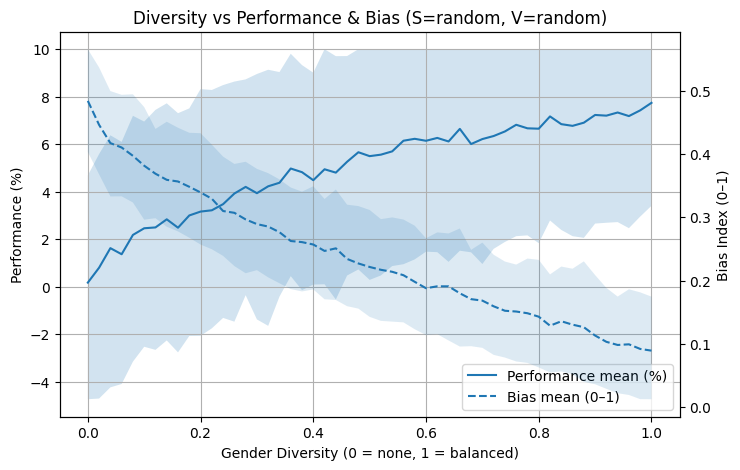

In [8]:
res = model()

Performance rises and Bias falls monotonically with increase in diversity, with the steepest gains at low D values (consistent with diminishing marginal dampening). The wide bands at low D indicate high uncertainty regarding the true effect of D in performance.

### Random, Linear Diversity Model

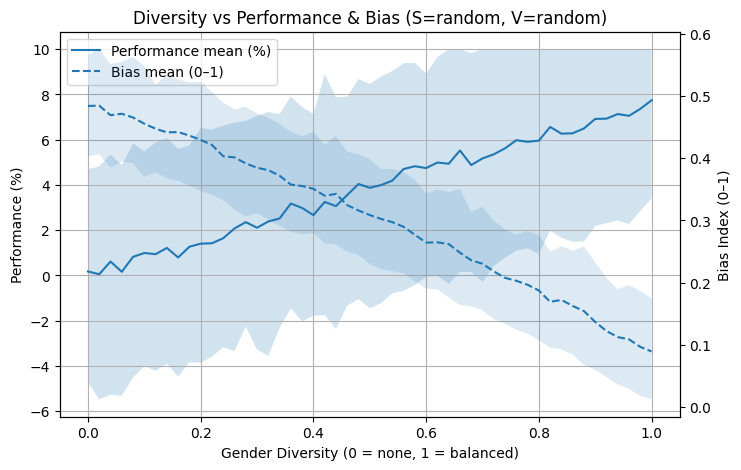

In [9]:
res = model(gamma=1.0)

The Performance–Bias relationship is approximately linear across D, with similar uncertainty at each level. Useful as a neutral benchmark against which γ≠1 effects can be judged.

### Random, Critical-Mass Diversity Model

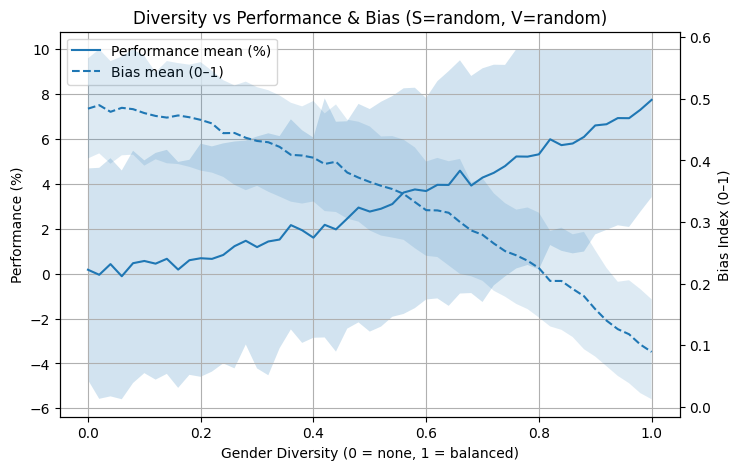

In [10]:
res = model(gamma=1.5)

Performance improves only modestly until D passes ~0.6–0.7, after which gains accelerate and Bias declines sharply. This suggests higher performance when there's a majority of females vs. a majority of males in portfolio teams.

### Maximum Positive Shock

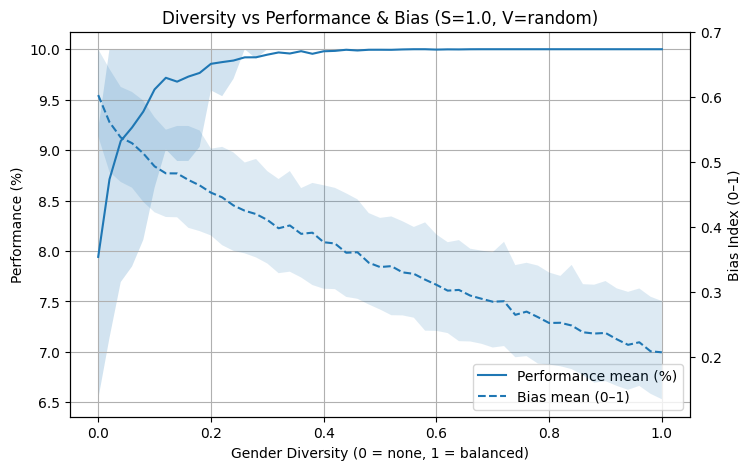

In [11]:
res = model(S_fixed=1.0)

With uniformely good news, Performance quickly saturates near the 10% cap as D increases, while Bias still declines with D. D stops being a factor which improves performance after 0.4 (although starts plateuing around 0.2) and it mainly compresses dispersion under tailwinds. This suggests that under strong positive externalities, these have a stronger effect on performance than diversity.

### No Market Shocks

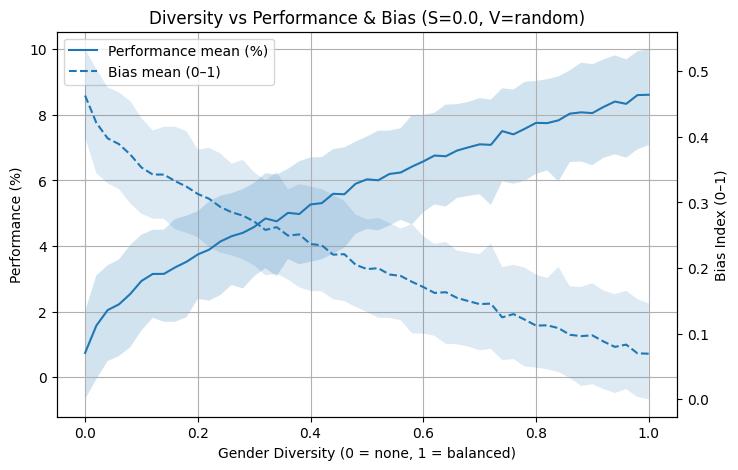

In [12]:
res = model(S_fixed=0.0)

In a neutral shock environment, the model produces clean, near-linear improvements in Performance and reductions in Bias with D. A lack of shocks significantly decreases uncertainity and variation around Bias Index and Performance, allowing to isolate diversity’s structural effect on them. A completely gender diverse team, however, does not achieve maximum performance. It also does not eliminate bias, suggesting an inherent level of cognitive biases in all individuals and investment teams.

### Maximum Negative Shock

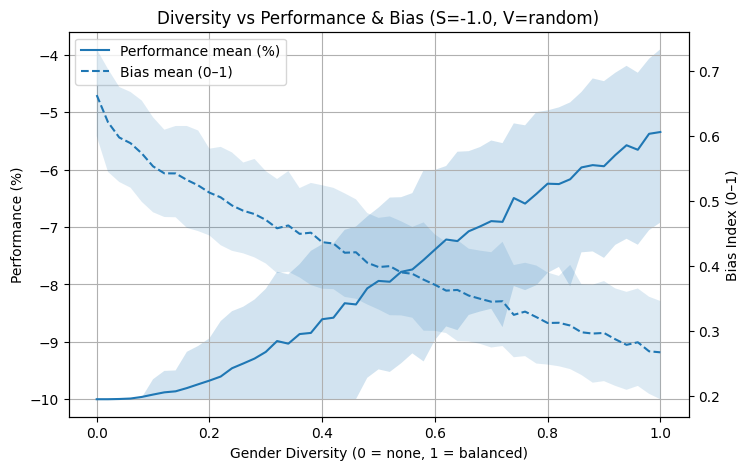

In [13]:
res = model(S_fixed=-1.0)

Even under the worst shock, greater D partially offsets elevated Bias and improves Performance toward less negative values. Diversity acts like a (partial) hedge in crises.

### Maximum Volatility

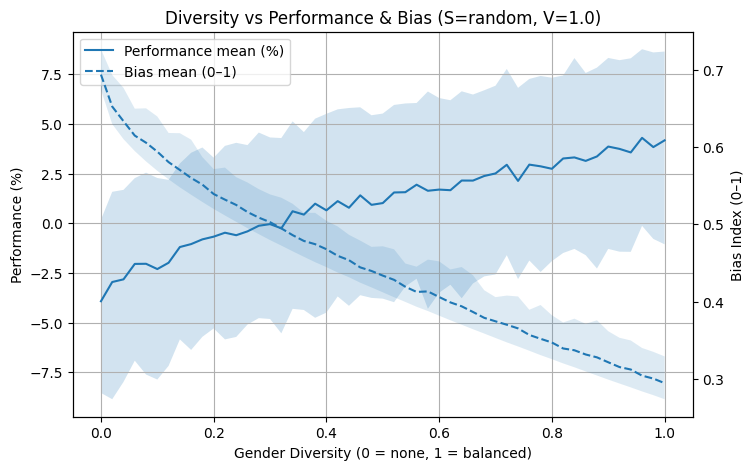

In [14]:
res = model(V_fixed=1.0)

High V makes Bias more centred, decreasing variations around the mean. It also drags Performance, especially at low D; increasing D steadily counteracts heuristic-driven distortions, though average returns are lower, with high volatile tails.

### Neutral Volatility

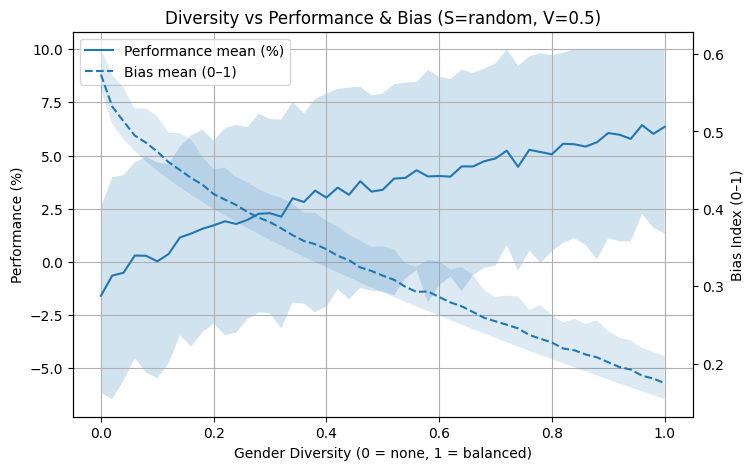

In [15]:
res = model(V_fixed=0.5)

At moderate V, the monotone D increases P and D decreases B patterns persist, however with tighter uncertainty. This is consistent with a stable information environment.

### No Volatility

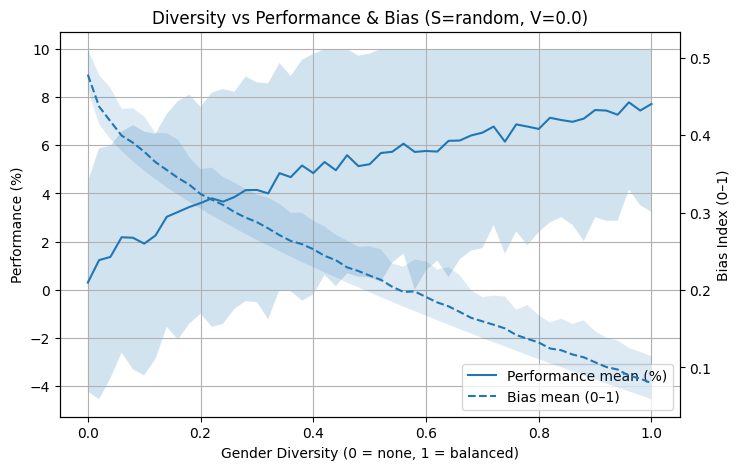

In [16]:
res = model(V_fixed=0.0)

When signals are clear, diversity still improves outcomes, but uncertainty bands becomes more disperse. Maximum performance can be achieved at D levels as low as 0.4. This suggests volatility is a key amplifier of both Bias and return dispersion, with D having a lower impact on V.

### Control Model: Neutral Shocks & Volatility Levels

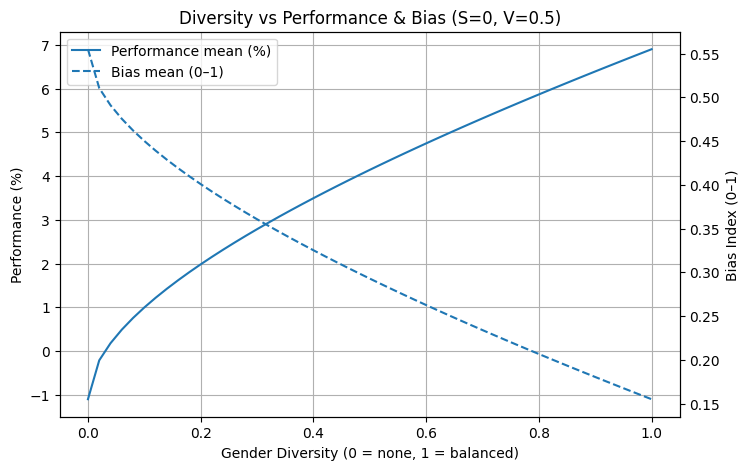

In [17]:
res = model(S_fixed=0, V_fixed=0.5)

The control produces smooth, interpretable gradients (↑P, ↓B with D), validating that observed non-linearities in other plots arise from γ, S, and V rather than artefacts.

# Discussion

Across all experiments, the model consistently shows that higher gender diversity lowers the Bias Index and raises average performance.
The largest gains appear when moving away from homogeneity, after which improvements as diversity increases plateau: once diversity is moderate, additional increases lead to smaller performance changes. In high-shock or high-volatility settings, diversity acts like a partial hedging mechanism; it softens the hit but does not dominate outcomes.
Turns out that a fully balanced team is not required for strong results: several scenarios reach near-top performance at $D<0.4$ (and, under extreme positive shocks, can reach as low as $D≈0.2$).

Dispersion in outcomes, however, is driven mainly by shocks and volatility. Diversity primarily shifts the mean of performance and bias; having nearly no effect on the dispersion of uncertainty bands.

Of course, this model offers a simplification of what variables might affect real-life investors. By aggregating biases at the team level, it assumes homogeneous teams that differ only by gender mix. Further on, it fixes bias weights, and stereotypes genders. Real investment teams vary on many dimensions (size, tenure, age, culture), and bias expression is individual and contextual. This means that our effect sizes are illustrative, rather than predictive. For example, younger investors would be more likely to suffer from overconfidence than senior investors, and so age might have more weight on a younger team. 

Because all of this, this model is only valid for homogenous investment teams, and not to highly diverse teams, individual traders, or algorithmic strategies. Further on, it is only valid under the assumption that gender is the biggest and/or only factor affecting the heuristics and biases of an investment team, and hence its effect on performance is likely to be over-weighted.

For future iterations of this model, it would be interesting to test how much effect diversity has on stock performance as team sizes increase, and if, at some point, it becomes irrelevant compared to the team size. To separate individual, or other effects on behaviours that decrease cognitive biases, adding separate variables that directly model due-diligence efforts and attitude towards risk would increase the soundness of the model.

# Conclusion

This paper formalises and tests a behavioural mechanism linking team gender composition to performance: greater gender diversity lowers $B$ and raises mean $P$, with the strongest marginal gains arising when moving away from homogeneity. Diversity has a partial hedge effect under shocks and high volatility. Benefits often taper at moderate $D$ when $γ<1$, while threshold-type gains emerge when $γ>1$. The model overweights the effect of diversity and performance and is only applicable to teams that are homogenous in all other aspects (such as age, cultural background, etc.). To improve the modelm we will explore alternative diversity shapes and team contexts, and extend the mechanism to include diligence channels so that individual context is better represented within the model.

# References

Amos Tversky, Daniel Kahneman ,_Judgment under Uncertainty: Heuristics and Biases_.Science185,1124-1131(1974).DOI:10.1126/science.185.4157.1124

Barber, B. M., & Odean, T. (2001). _The internet and the investor_. Journal of Economic Perspectives, 15(1), 41-54.

Bloom, N. (2009). _The impact of uncertainty shocks_. econometrica, 77(3), 623-685.

Maqsood Ahmad, Syed Zulfiqar Ali Shah; _Overconfidence heuristic-driven bias in investment decision-making and performance: mediating effects of risk perception and moderating effects of financial literacy_. Journal of Economic and Administrative Sciences 1 February 2022; 38 (1): 60–90. https://doi.org/10.1108/JEAS-07-2020-0116